In [2]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader


In [5]:
# Set device to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [4]:
"""Data Preprocessing and Loading"""

# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}



# Print class labels
class_names = ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
print("Class Labels:", class_names)
num_classes = len(class_names)

Class Labels: ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


Model loaded successfully!


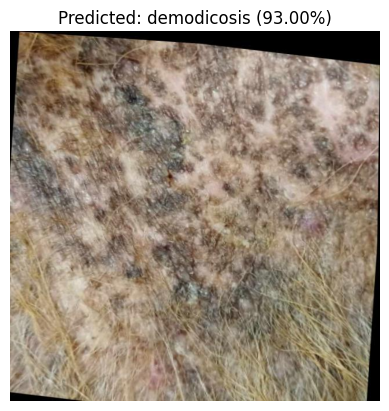

('demodicosis', 92.99768805503845)

In [7]:

# Load model
loaded_model = models.mobilenet_v2(pretrained=False)
loaded_model.classifier[1] = nn.Linear(loaded_model.last_channel, num_classes)
loaded_model = loaded_model.to(device)
loaded_model.load_state_dict(torch.load('dog_skin_disease_MobileNetV2.pth'))
loaded_model.eval()
print("Model loaded successfully!")


def predict_single_image(model, image_path, class_names):
    from PIL import Image
    
    # Load and preprocess image
    img = Image.open(image_path)
    transform = data_transforms['test']
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # Make prediction
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)
    
    # Get predicted class name and confidence
    predicted_class = class_names[pred.item()]
    confidence = conf.item() * 100
    
    # Display image and prediction
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.show()
    
    return predicted_class, confidence

 # Example usage
predict_single_image(loaded_model, "./1-24.jpg", class_names)  